# Problemas de Regresión en Aprendizaje Supervisado

In [1]:
# Importar librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## 1. Introducción a la Regresión

La regresión supervisada es una técnica para predecir un valor numérico continuo a partir de variables de entrada (features).

Ejemplos típicos:

- Predecir el precio de una casa según sus características.

- Predecir la temperatura o la demanda energética.

- Estimar la duración de un proceso industrial.

## 2. Dataset de ejemplo

Vamos a crear un dataset sintético para ilustrar.

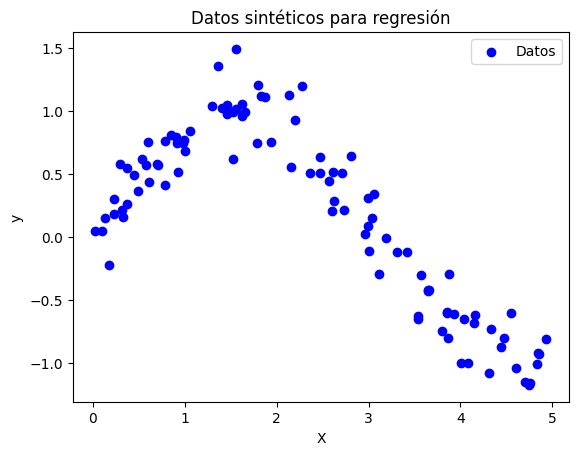

In [2]:
# Crear dataset sintético: relación no lineal
np.random.seed(42)
X = np.sort(5 * np.random.rand(100, 1), axis=0)  # Variable independiente (feature)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])  # Variable objetivo con ruido

# Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Graficar dataset
plt.scatter(X, y, color='blue', label='Datos')
plt.title("Datos sintéticos para regresión")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


## 3. Regresión Lineal

Concepto:

Modelo que asume una relación lineal entre la variable independiente y la variable dependiente.

![Regresión Lineal](reglineal.png)


Se busca ajustar los coeficientes β0 y β1​ para minimizar el error cuadrático.

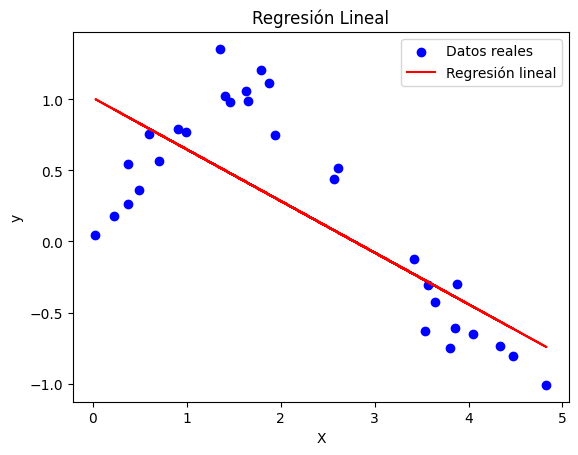

In [4]:
# Entrenar modelo regresión lineal
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predecir en test
y_pred_lin = lin_reg.predict(X_test)

# Graficar
plt.scatter(X_test, y_test, color='blue', label='Datos reales')
plt.plot(X_test, y_pred_lin, color='red', label='Regresión lineal')
plt.title("Regresión Lineal")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


### 4. Regresión Polinomial

Concepto:

Se extiende la regresión lineal para modelar relaciones no lineales incluyendo potencias de la variable x:

![Regresión Polinomial](regpoli.png)

Donde d es el grado del polinomio.

#### ¿Qué es el grado d en regresión polinomial?

El grado d indica el grado máximo del polinomio que usaremos para modelar la relación entre las variables independientes (features) y la variable dependiente (target).

Por ejemplo:

- Si d=1, la regresión polinomial es en realidad una regresión lineal simple (modelo lineal).

- Si d=3, el modelo incluye términos hasta x³

#### ¿Se debe entrenar el grado d?

No, el grado no es un parámetro que el modelo "aprenda" directamente durante el entrenamiento como los coeficientes β.

El grado d es un hiperparámetro que se debe definir antes del entrenamiento.

#### ¿Cómo elegir el grado d?

- Se elige probando distintos valores (por ejemplo, d=1,2,3,4,5) y evaluando cuál da el mejor balance entre sesgo y varianza.


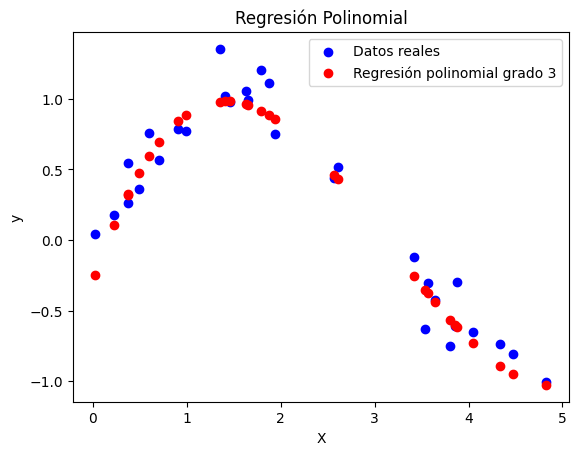

In [5]:
# Transformar variables para polinomial grado 3
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Entrenar regresión lineal con variables polinomiales
poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

# Predecir
y_pred_poly = poly_reg.predict(X_test_poly)

# Graficar
plt.scatter(X_test, y_test, color='blue', label='Datos reales')
plt.scatter(X_test, y_pred_poly, color='red', label='Regresión polinomial grado 3')
plt.title("Regresión Polinomial")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


En la regresion lineal y polinomial se usa generalmente el método de **gradient descent** para ajustar los parametros.

### Cómo se evaluan los modelos en los problemas de regresión?

En problemas de regresión, usamos varias métricas para evaluar qué tan bien nuestro modelo predice los valores reales. A continuación, se describen cuatro métricas comunes, indicando su escala y el valor óptimo:

- **Error Absoluto Medio (MAE - Mean Absolute Error):**

![MAE](mae.png)

Interpretación: Promedio de la magnitud del error en las mismas unidades que la variable objetivo.

Escala: Desde 0 hasta infinito.

Mejor valor: 0 (error perfecto).

Cuanto más bajo, mejor.

- **Error Cuadrático Medio (MSE - Mean Squared Error):**

![MSE](mse.png)

Interpretación: Promedio del error al cuadrado; penaliza más los errores grandes.

Escala: Desde 0 hasta infinito.

Mejor valor: 0 (error perfecto).

Cuanto más bajo, mejor.

- **Raíz del Error Cuadrático Medio (RMSE - Root Mean Squared Error):**

![RMSE](rmse.png)

Interpretación: Raíz cuadrada del MSE; error promedio en unidades originales.

Escala: Desde 0 hasta infinito.

Mejor valor: 0 (error perfecto).

Cuanto más bajo, mejor.

- **Coeficiente de Determinación R2 (R-cuadrado):**

![R2](r2.png)

Interpretación: Proporción de la varianza explicada por el modelo.

Escala: Generalmente entre −∞ y 1 (puede ser negativo si el modelo es peor que la media).

Mejor valor: 1 (modelo explica toda la variabilidad).

Cuanto más cercano a 1, mejor.

In [6]:
def evaluar_modelo(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")

print("Evaluación Regresión Lineal:")
evaluar_modelo(y_test, y_pred_lin)
print("\nEvaluación Regresión Polinomial grado 3:")
evaluar_modelo(y_test, y_pred_poly)


Evaluación Regresión Lineal:
MSE: 0.2199
RMSE: 0.4690
MAE: 0.3888
R²: 0.5550

Evaluación Regresión Polinomial grado 3:
MSE: 0.0270
RMSE: 0.1643
MAE: 0.1302
R²: 0.9454


### Arbol de regresión

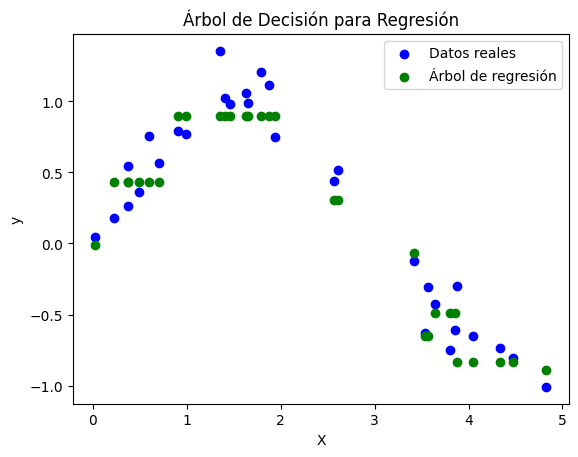

In [7]:
# Entrenar árbol de regresión
tree_reg = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_reg.fit(X_train, y_train)

# Predecir
y_pred_tree = tree_reg.predict(X_test)

# Graficar
plt.scatter(X_test, y_test, color='blue', label='Datos reales')
plt.scatter(X_test, y_pred_tree, color='green', label='Árbol de regresión')
plt.title("Árbol de Decisión para Regresión")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


#### Random Forest para regresión

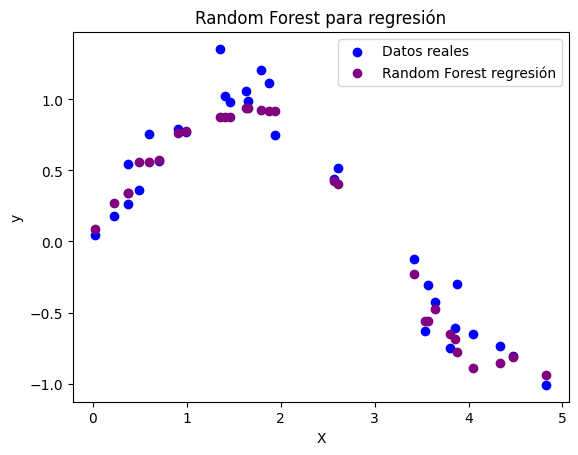

In [8]:
rf_reg = RandomForestRegressor(n_estimators=50, max_depth=4, random_state=42)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

# Graficar
plt.scatter(X_test, y_test, color='blue', label='Datos reales')
plt.scatter(X_test, y_pred_rf, color='purple', label='Random Forest regresión')
plt.title("Random Forest para regresión")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


#### Gradient Boosting para regresión

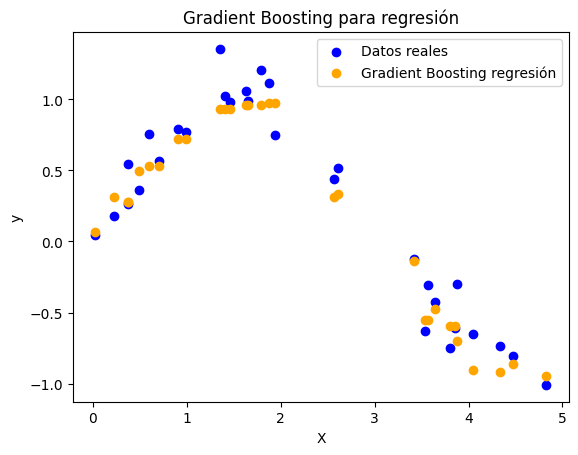

In [9]:
gb_reg = GradientBoostingRegressor(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42)
gb_reg.fit(X_train, y_train)
y_pred_gb = gb_reg.predict(X_test)

# Graficar
plt.scatter(X_test, y_test, color='blue', label='Datos reales')
plt.scatter(X_test, y_pred_gb, color='orange', label='Gradient Boosting regresión')
plt.title("Gradient Boosting para regresión")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


#### Evaluar los modelos de árbol y ensembles

In [10]:
print("Evaluación Árbol de regresión:")
evaluar_modelo(y_test, y_pred_tree)
print("\nEvaluación Random Forest regresión:")
evaluar_modelo(y_test, y_pred_rf)
print("\nEvaluación Gradient Boosting regresión:")
evaluar_modelo(y_test, y_pred_gb)


Evaluación Árbol de regresión:
MSE: 0.0441
RMSE: 0.2100
MAE: 0.1717
R²: 0.9108

Evaluación Random Forest regresión:
MSE: 0.0328
RMSE: 0.1810
MAE: 0.1369
R²: 0.9337

Evaluación Gradient Boosting regresión:
MSE: 0.0303
RMSE: 0.1741
MAE: 0.1357
R²: 0.9387
